<a href="https://colab.research.google.com/github/SapuiSoumyajit/soumyajit_pythonproject/blob/main/notebook/train_yolov12_object_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Check GPU availability

**NOTE:** **YOLOv12 leverages FlashAttention to speed up attention-based computations, but this feature requires an Nvidia GPU built on the Ampere architecture or newer—for example, GPUs like the RTX 3090, RTX 3080, or even the Nvidia L4 meet this requirement.**

Let's make sure that we have access to GPU. We can use `nvidia-smi` command to do that. In case of any problems navigate to `Edit` -> `Notebook settings` -> `Hardware accelerator`, set it to `GPU`, and then click `Save`.

In [ ]:
!nvidia-smi

Thu Mar 26 15:59:10 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             10W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

### Install dependencies

**NOTE:** Currently, YOLOv12 does not have its own PyPI package, so we install it directly from GitHub while also adding roboflow (to conveniently pull datasets from the Roboflow Universe), supervision (to visualize inference results and benchmark the model’s performance), and flash-attn (to accelerate attention-based computations via optimized CUDA kernels).

### Download example data

Let's download an image we can use for YOLOv12 inference. Feel free to drag and drop your own images into the Files tab on the left-hand side of Google Colab, then reference their filenames in your code for a custom inference demo.

## Download dataset from Roboflow Universe

In [ ]:
!pip install ultralytics roboflow

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 36.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.8/95.8 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 20.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 76.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 139.6 MB/s eta 0:00:00
  Attempting uninstall: opencv-python-headless
    Found existing installation: opencv-python-headless 4.13.0.92
    Uninstalling opencv-python-headless-4.13.0.92:
      Successfully uninstalled opencv-python-headless-4.13.0.92
  Attempting uninstall: idna
    Found existing installation: idna 3.11
    Uninstalling idna-3.11:
      Successfully uninstalled idna-3.11


In [ ]:




from roboflow import Roboflow
rf = Roboflow(api_key="RzESlaLw2hrACP13NVmz")
project = rf.workspace("potholes-r7qcn").project("pothole-jujbl")
dataset = project.version(1).download("yolov8")


loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to Pothole-1 in yolov8:: 100%|██████████| 5554/5554 [00:00<00:00, 7515.17it/s]


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data=dataset.location + "/data.yaml",
    epochs=50,
    imgsz=640,
    batch=16,
    lr0=0.001
)

Ultralytics 8.4.29 🚀 Python-3.12.13 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/Pothole-1/data.yaml, degrees=0.0, deterministic=True, device=None, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.001, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=train, nbs=64, nms=False, opset=None, optimize=False, optimizer=auto, overlap_mask=True, patience=100, perspective

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7cb70446f9b0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0.048048, 

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt

model = YOLO("runs/detect/train/weights/best.pt")

results = model(dataset.location + "/test/images", save=True)


image 1/277 /content/Pothole-1/test/images/potholes100_png_jpg.rf.44c165e751cdc47ee470079637361cab.jpg: 640x640 1 Pothole, 14.8ms
image 2/277 /content/Pothole-1/test/images/potholes100_png_jpg.rf.ebe411bb92a77691b1679660833a7cd3.jpg: 640x640 2 Potholes, 13.5ms
image 3/277 /content/Pothole-1/test/images/potholes101_png_jpg.rf.54b95345d8d9481131bc3f2cfbc20480.jpg: 640x640 3 Potholes, 10.7ms
image 4/277 /content/Pothole-1/test/images/potholes104_png_jpg.rf.ef7cfe76c87260098d38bfe5b04728c2.jpg: 640x640 2 Potholes, 9.8ms
image 5/277 /content/Pothole-1/test/images/potholes105_png_jpg.rf.7c6b647a0f4a2a2e839f61e41e8222b9.jpg: 640x640 9 Potholes, 9.4ms
image 6/277 /content/Pothole-1/test/images/potholes110_png_jpg.rf.83faa96c55c95d4f475626a86b16317b.jpg: 640x640 4 Potholes, 9.9ms
image 7/277 /content/Pothole-1/test/images/potholes111_png_jpg.rf.3ba408cea5573a431bf71847748acd78.jpg: 640x640 1 Pothole, 9.4ms
image 8/277 /content/Pothole-1/test/images/potholes111_png_jpg.rf.f788a1f88fb4eee587f9a3


image 1/1 /content/Pothole.jpg: 384x640 18 Potholes, 40.9ms
Speed: 3.1ms preprocess, 40.9ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)


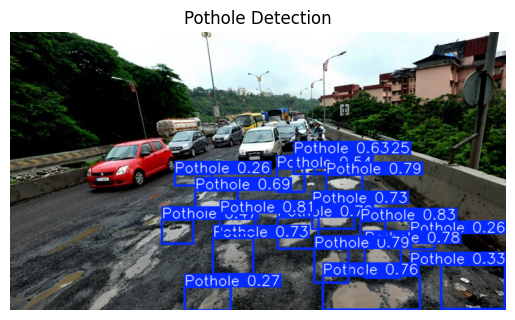

In [ ]:
import cv2
import matplotlib.pyplot as plt

def detect_image(image_path):
    results = model(image_path)


    img = results[0].plot()

    plt.imshow(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("Pothole Detection")
    plt.show()


detect_image("/content/Pothole.jpg")

In [ ]:
from ultralytics import YOLO
import cv2

model = YOLO("runs/detect/train/weights/best.pt")

def detect_video_save(video_path, output_path="output.mp4"):
    cap = cv2.VideoCapture(video_path)

    width = int(cap.get(3))
    height = int(cap.get(4))
    fps = int(cap.get(cv2.CAP_PROP_FPS))

    out = cv2.VideoWriter(
        output_path,
        cv2.VideoWriter_fourcc(*'mp4v'),
        fps,
        (width, height)
    )

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        results = model(frame)
        annotated_frame = results[0].plot()

        out.write(annotated_frame)

    cap.release()
    out.release()
    print("Video saved as", output_path)

detect_video_save("/content/mixkit-potholes-in-a-rural-road-25208-hd-ready.mp4")


0: 384x640 16 Potholes, 10.2ms
Speed: 2.1ms preprocess, 10.2ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 13 Potholes, 7.7ms
Speed: 1.9ms preprocess, 7.7ms inference, 1.4ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 17 Potholes, 8.9ms
Speed: 2.4ms preprocess, 8.9ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 17 Potholes, 7.2ms
Speed: 2.8ms preprocess, 7.2ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 16 Potholes, 6.3ms
Speed: 3.0ms preprocess, 6.3ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 16 Potholes, 8.5ms
Speed: 2.5ms preprocess, 8.5ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 19 Potholes, 7.1ms
Speed: 2.6ms preprocess, 7.1ms inference, 1.3ms postprocess per image at shape (1, 3, 384, 640)

0: 384x640 17 Potholes, 6.8ms
Speed: 2.3ms preprocess, 6.8ms inference, 1.3ms postprocess per image at shape

In [ ]:
from google.colab import files
files.download("output.mp4")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
import os

print(os.listdir("runs/detect/train/weights"))

In [ ]:
from google.colab import files

files.download("runs/detect/train/weights/best.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>